# InsectSet66 — Baseline replication (mel-CNN)

Replicates the **mel-spectrogram + CNN** pipeline from Faiss et al. (2023):
- Paper: [10.1371/journal.pcbi.1011541](https://doi.org/10.1371/journal.pcbi.1011541)
- Code: [InsectSet47-InsectSet66-Adaptive-Representations...](https://github.com/mariusfaiss/InsectSet47-InsectSet66-Adaptive-Representations-of-Sound-for-Automatic-Insect-Recognition)

**Pipeline:** 5 s chunks (3.75 s overlap) → Mel spectrogram (64 bands) → 4- or 5-layer CNN → train/val early stopping → test metrics.

Set `FAST_DEV = True` for a quick smoke run (~minutes). Set `FAST_DEV = False` for full replication (hours; GPU/MPS recommended).

In [ ]:
# %pip install -q torch torchaudio librosa soundfile pandas scikit-learn matplotlib seaborn tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import json
import random
import shutil
import warnings
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from torch import nn
from torch.nn import init
from torch.utils.data import DataLoader, Dataset
from torchaudio import transforms
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Repro settings (match LEAF_Mel_Model.py defaults for dataset 66, MEL frontend) ---
FAST_DEV = False          # True: small subset, few epochs | False: full replication
REBUILD_MANIFEST = False  # True only if you deleted data/cache/baseline_mel_chunks/
VALIDATE_MANIFEST = False  # scan chunk WAVs and drop broken rows before training
FRONTEND = "MEL"
LAYERS = 4 if FAST_DEV else 5   # paper: ~78% (4 conv), ~82% (5 conv) mel on InsectSet66
SEED = 1000
SAMPLE_RATE = 44100
AUDIO_LEN = 5
N_MELS = 64
HOP_LENGTH = int((SAMPLE_RATE * 5) / 1500)  # 147
TOP_DB = 80
BATCH_SIZE = 14 if not FAST_DEV else 8
WEIGHT_DECAY = 0.001
DROPOUT = 0.23
MAX_PATIENCE = 8
NUM_EPOCHS = 3 if FAST_DEV else 1000
EARLY_STOP = not FAST_DEV
AUGMENTATION = False  # paper uses IR+noise; needs OpenAIR IR folder — enable after downloading IRs

CHUNK_LENGTH = 5.0
OVERLAP = 3.75
MIN_LENGTH = 1.25

ROOT = Path(".").resolve()
DATA_DIR = ROOT / "data"
CSV_PATH = DATA_DIR / "InsectSet66_Train_Val_Test_Annotation.csv"
AUDIO_DIR = DATA_DIR / "InsectSet66_Train_Val_Test"
SPECIES_ORDER_PATH = DATA_DIR / "66_species_order.csv"
CACHE_DIR = DATA_DIR / "cache" / "baseline_mel_chunks"
RESULTS_DIR = ROOT / "results" / "baseline_replication"
MANIFEST_PATH = CACHE_DIR / "manifest.csv"

for p in [CACHE_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

assert CSV_PATH.exists(), CSV_PATH
assert AUDIO_DIR.is_dir(), AUDIO_DIR
assert SPECIES_ORDER_PATH.exists(), SPECIES_ORDER_PATH

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device} | FAST_DEV={FAST_DEV} | layers={LAYERS} | augmentation={AUGMENTATION}")

Device: mps | FAST_DEV=False | layers=5 | augmentation=False


In [4]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)


def load_species_order(path: Path) -> list[str]:
    lines = path.read_text(encoding="utf-8-sig").strip().splitlines()
    return [ln.strip() for ln in lines if ln.strip()]


species_order = load_species_order(SPECIES_ORDER_PATH)
assert len(species_order) == 66
class_to_id = {name: i for i, name in enumerate(species_order)}
id_to_class = {i: name for name, i in class_to_id.items()}
NUM_CLASSES = len(species_order)
print(f"Classes: {NUM_CLASSES}")

Classes: 66


## 1. Audio chunking (same logic as `SplitAudioChunks.py`)

Chunks are written under `data/cache/baseline_mel_chunks/` once; reuse via `manifest.csv`.

In [5]:
BUFFER = int(CHUNK_LENGTH * SAMPLE_RATE)
OVERLAP_SAMPLES = int(OVERLAP * SAMPLE_RATE)
MIN_SAMPLES = int(MIN_LENGTH * SAMPLE_RATE)


def iter_chunks(y: np.ndarray) -> list[np.ndarray]:
    """Mirror official SplitAudioChunks.py for one waveform."""
    chunks = []
    n = len(y)

    if n < BUFFER:
        loop = y
        count = int(BUFFER / n) + (1 if BUFFER % n > 0 else 0)
        for _ in range(1, count):
            loop = np.concatenate([loop, y])
        chunks.append(loop[:BUFFER].astype(np.float32))
        return chunks

    wrote = 0
    counter = 1
    while wrote < n:
        remaining = n - wrote
        if remaining >= BUFFER:
            chunks.append(y[wrote : wrote + BUFFER].astype(np.float32))
            counter += 1
            wrote = int(wrote + BUFFER - OVERLAP_SAMPLES)
        else:
            if remaining > MIN_SAMPLES:
                wrap_len = int(BUFFER - remaining)
                wrap = y[:wrap_len]
                chunk = y[wrote : wrote + BUFFER]
                wrapped = np.concatenate([chunk, wrap])[:BUFFER]
                chunks.append(wrapped.astype(np.float32))
            break
    return chunks


def build_manifest(force: bool = False, max_per_subset: int | None = None) -> pd.DataFrame:
    if MANIFEST_PATH.exists() and not force:
        m = pd.read_csv(MANIFEST_PATH)
        print(f"Loaded manifest: {len(m)} chunks from {MANIFEST_PATH}")
        return m

    df = pd.read_csv(CSV_PATH)
    rows = []
    for subset in ["train", "validation", "test"]:
        sub = df[df["subset"] == subset]
        if max_per_subset:
            sub = sub.head(max_per_subset)
        out_dir = CACHE_DIR / subset
        out_dir.mkdir(parents=True, exist_ok=True)

        for _, r in tqdm(sub.iterrows(), total=len(sub), desc=f"Chunk {subset}"):
            wav_path = AUDIO_DIR / r["file_name"]
            if not wav_path.exists():
                continue
            sp = r["species"]
            if sp not in class_to_id:
                raise KeyError(f"Unknown species {sp!r} in {r['file_name']}")
            y, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True)
            stem = wav_path.stem
            for i, chunk in enumerate(iter_chunks(y)):
                out_name = f"{stem}_chunk{i}.wav"
                out_path = out_dir / out_name
                sf.write(out_path, chunk, SAMPLE_RATE)
                rows.append({
                    "path_name": str(out_path),
                    "classID": class_to_id[sp],
                    "species_name": sp,
                    "subset": subset,
                })

    manifest = pd.DataFrame(rows)
    manifest.to_csv(MANIFEST_PATH, index=False)
    print(f"Wrote {len(manifest)} chunks -> {MANIFEST_PATH}")
    return manifest


def validate_and_clean_manifest(m: pd.DataFrame) -> pd.DataFrame:
    """Drop chunk rows that are missing or unreadable (prevents LibsndfileError in training)."""
    from concurrent.futures import ThreadPoolExecutor, as_completed

    def _ok(path_str: str) -> bool:
        p = Path(path_str)
        if not p.is_file() or p.stat().st_size < 1000:
            return False
        try:
            info = sf.info(p)
            return info.frames > 1000
        except Exception:
            return False

    paths = m["path_name"].astype(str).tolist()
    good = set()
    with ThreadPoolExecutor(max_workers=16) as ex:
        futs = {ex.submit(_ok, p): p for p in paths}
        for fut in tqdm(as_completed(futs), total=len(futs), desc="Validate chunks"):
            p = futs[fut]
            try:
                if fut.result(timeout=8):
                    good.add(p)
            except Exception:
                pass

    clean = m[m["path_name"].astype(str).isin(good)].reset_index(drop=True)
    dropped = len(m) - len(clean)
    if dropped:
        print(f"Removed {dropped} bad chunk paths from manifest")
        backup = MANIFEST_PATH.with_suffix(".csv.bak")
        if not backup.exists() and MANIFEST_PATH.exists():
            shutil.copy2(MANIFEST_PATH, backup)
        clean.to_csv(MANIFEST_PATH, index=False)
    else:
        print("All chunk paths OK")
    return clean


max_files = 30 if FAST_DEV else None
manifest = build_manifest(force=REBUILD_MANIFEST, max_per_subset=max_files)
if VALIDATE_MANIFEST:
    manifest = validate_and_clean_manifest(manifest)
manifest.groupby("subset").size()

Loaded manifest: 64290 chunks from /Users/ali/Desktop/thesis/audio/data/cache/baseline_mel_chunks/manifest.csv


subset
test          10391
train         41312
validation    12587
dtype: int64

## 2. Dataset & mel-CNN model (from `LEAF_Mel_Model.py`, MEL only)

In [6]:
class SoundDS(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.frame = frame.reset_index(drop=True)

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        path = self.frame.loc[idx, "path_name"]
        class_id = int(self.frame.loc[idx, "classID"])
        try:
            y, _ = sf.read(path, dtype="float32")
        except Exception:
            y = librosa.load(path, sr=SAMPLE_RATE, mono=True, duration=AUDIO_LEN)[0]
        if y.ndim > 1:
            y = y.mean(axis=1)
        sig = torch.from_numpy(y).unsqueeze(0)  # [1, T]
        target_len = SAMPLE_RATE * AUDIO_LEN
        if sig.size(1) < target_len:
            sig = F.pad(sig, (0, target_len - sig.size(1)))
        elif sig.size(1) > target_len:
            sig = sig[:, :target_len]
        return sig, class_id


train_df = manifest[manifest["subset"] == "train"]
val_df = manifest[manifest["subset"] == "validation"]
test_df = manifest[manifest["subset"] == "test"]

train_ds = SoundDS(train_df)
val_ds = SoundDS(val_df)
test_ds = SoundDS(test_df)


def seed_worker(worker_id):
    w = torch.initial_seed() % 2**32
    np.random.seed(w)
    random.seed(w)


g = torch.Generator().manual_seed(SEED)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
                      worker_init_fn=seed_worker, generator=g)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Chunks — train: {len(train_ds)}, val: {len(val_ds)}, test: {len(test_ds)}")

Chunks — train: 41312, val: 12587, test: 10391


In [7]:
class AudioClassifier(nn.Module):
    """Mel frontend + CNN (official AudioClassifier, MEL branch only)."""

    def __init__(self, n_classes: int, n_layers: int = 4, dropout: float = DROPOUT):
        super().__init__()
        self.augment_train = False
        self.spectrogram = transforms.MelSpectrogram(
            sample_rate=SAMPLE_RATE,
            n_mels=N_MELS,
            hop_length=HOP_LENGTH,
            n_fft=1000,
            f_max=SAMPLE_RATE / 2,
            win_length=HOP_LENGTH * 2,
        )
        self.amp_db = transforms.AmplitudeToDB(top_db=TOP_DB)

        conv_layers = []
        self.conv1 = nn.Conv2d(1, 8, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
        self.relu1 = nn.ReLU()
        self.bn1 = nn.BatchNorm2d(8)
        init.kaiming_normal_(self.conv1.weight, a=0.1)
        self.conv1.bias.data.zero_()
        conv_layers += [self.conv1, self.relu1, self.bn1]

        self.conv2 = nn.Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu2 = nn.ReLU()
        self.bn2 = nn.BatchNorm2d(16)
        init.kaiming_normal_(self.conv2.weight, a=0.1)
        self.conv2.bias.data.zero_()
        conv_layers += [self.conv2, self.relu2, self.bn2]

        self.conv3 = nn.Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu3 = nn.ReLU()
        self.bn3 = nn.BatchNorm2d(32)
        init.kaiming_normal_(self.conv3.weight, a=0.1)
        self.conv3.bias.data.zero_()
        conv_layers += [self.conv3, self.relu3, self.bn3]

        self.conv4 = nn.Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        self.relu4 = nn.ReLU()
        self.bn4 = nn.BatchNorm2d(64)
        init.kaiming_normal_(self.conv4.weight, a=0.1)
        self.conv4.bias.data.zero_()
        conv_layers += [self.conv4, self.relu4, self.bn4]

        feat = 64
        if n_layers == 5:
            self.conv5 = nn.Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
            self.relu5 = nn.ReLU()
            self.bn5 = nn.BatchNorm2d(128)
            init.kaiming_normal_(self.conv5.weight, a=0.1)
            self.conv5.bias.data.zero_()
            conv_layers += [self.conv5, self.relu5, self.bn5]
            feat = 128

        self.conv = nn.Sequential(*conv_layers)
        self.ap = nn.AdaptiveAvgPool2d(1)
        self.lin = nn.Linear(feat, n_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.spectrogram(x)
        x = self.amp_db(x)
        x = self.conv(x)
        x = self.ap(x)
        x = x.view(x.shape[0], -1)
        x = self.lin(x)
        x = self.dropout(x)
        return x


def normalize_batch(inputs: torch.Tensor) -> torch.Tensor:
    m, s = inputs.mean(), inputs.std()
    return (inputs - m) / (s + 1e-8)


model = AudioClassifier(NUM_CLASSES, n_layers=LAYERS).to(device)
print(model.__class__.__name__, "params:", sum(p.numel() for p in model.parameters()))

AudioClassifier params: 107378


## 3. Training (Adam + OneCycleLR + early stopping on validation loss)

In [8]:
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, train: bool = True):
    model.train() if train else model.eval()
    total_loss = 0.0
    correct, total = 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for inputs, labels in loader:
            inputs = normalize_batch(inputs.to(device))
            labels = labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                if scheduler is not None:
                    scheduler.step()
            total_loss += loss.item()
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

    return total_loss / max(len(loader), 1), correct / max(total, 1)


def train_model(model, train_dl, val_dl, num_epochs: int):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.001, steps_per_epoch=max(len(train_dl), 1),
        epochs=num_epochs, anneal_strategy="linear",
    )

    best_path = RESULTS_DIR / f"mel_{SEED}_best.pth"
    history = []
    patience, best_val_loss, checkpoint = 0, float("inf"), 0

    for epoch in range(num_epochs):
        tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, train=True)
        va_loss, va_acc = run_epoch(model, val_dl, criterion, train=False)
        history.append({"epoch": epoch + 1, "train_loss": tr_loss, "train_acc": tr_acc,
                        "val_loss": va_loss, "val_acc": va_acc})
        print(f"E{epoch+1} train loss {tr_loss:.3f} acc {tr_acc:.3f} | val loss {va_loss:.3f} acc {va_acc:.3f}")

        if not EARLY_STOP:
            torch.save(model.state_dict(), best_path)
            checkpoint = epoch + 1
            continue

        if epoch == 0 or va_loss <= best_val_loss:
            patience = 0
            best_val_loss = va_loss
            checkpoint = epoch + 1
            torch.save(model.state_dict(), best_path)
            print(f"  -> saved checkpoint epoch {checkpoint}")
        else:
            patience += 1
            print(f"  patience {patience}/{MAX_PATIENCE}")
            if patience >= MAX_PATIENCE:
                print("Early stop.")
                break

    pd.DataFrame(history).to_csv(RESULTS_DIR / "training_history.csv", index=False)
    return best_path, checkpoint, history


best_path, best_epoch, history = train_model(model, train_dl, val_dl, NUM_EPOCHS)
print("Best weights:", best_path, "epoch", best_epoch)

/Users/ali/Desktop/thesis/audio/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [14, 1501, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]
/Users/ali/Desktop/thesis/audio/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [12, 1501, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reu

E1 train loss 3.088 acc 0.335 | val loss 3.004 acc 0.334
  -> saved checkpoint epoch 1
E2 train loss 2.266 acc 0.522 | val loss 2.679 acc 0.396
  -> saved checkpoint epoch 2
E3 train loss 1.954 acc 0.591 | val loss 2.578 acc 0.417
  -> saved checkpoint epoch 3
E4 train loss 1.775 acc 0.630 | val loss 2.464 acc 0.434
  -> saved checkpoint epoch 4
E5 train loss 1.628 acc 0.656 | val loss 2.393 acc 0.456
  -> saved checkpoint epoch 5
E6 train loss 1.504 acc 0.677 | val loss 2.305 acc 0.466
  -> saved checkpoint epoch 6
E7 train loss 1.379 acc 0.692 | val loss 2.274 acc 0.481
  -> saved checkpoint epoch 7
E8 train loss 1.265 acc 0.701 | val loss 2.251 acc 0.486
  -> saved checkpoint epoch 8
E9 train loss 1.165 acc 0.709 | val loss 2.265 acc 0.507
  patience 1/8
E10 train loss 1.088 acc 0.717 | val loss 2.218 acc 0.506
  -> saved checkpoint epoch 10
E11 train loss 1.019 acc 0.726 | val loss 2.247 acc 0.521
  patience 1/8
E12 train loss 0.992 acc 0.726 | val loss 2.245 acc 0.521
  patience 2

## 4. Test evaluation (accuracy + macro F1 / precision / recall)

In [9]:
def evaluate_test(model, test_dl):
    model.eval()
    y_true, y_pred = [], []
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in test_dl:
            inputs = normalize_batch(inputs.to(device))
            labels = labels.to(device)
            outputs = model(inputs)
            pred = outputs.argmax(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(pred.cpu().numpy())

    acc = correct / max(total, 1)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_true, y_pred, average="macro", zero_division=0)
    return {"accuracy": acc, "macro_f1": f1, "macro_precision": prec, "macro_recall": rec}, y_true, y_pred


model.load_state_dict(torch.load(best_path, map_location=device))
metrics, y_true, y_pred = evaluate_test(model, test_dl)

print("Test metrics:")
for k, v in metrics.items():
    print(f"  {k}: {v:.4f}")

summary = {
    "frontend": FRONTEND,
    "layers": LAYERS,
    "seed": SEED,
    "fast_dev": FAST_DEV,
    "augmentation": AUGMENTATION,
    "best_epoch": best_epoch,
    "train_chunks": len(train_ds),
    "val_chunks": len(val_ds),
    "test_chunks": len(test_ds),
    **metrics,
    "paper_reference_mel_insectset66": "~0.78 median (4 conv) / ~0.82 (5 conv) accuracy — Faiss et al. 2023 Table 4",
}
(RESULTS_DIR / "summary.json").write_text(json.dumps(summary, indent=2))
print("Saved", RESULTS_DIR / "summary.json")

/Users/ali/Desktop/thesis/audio/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [14, 1501, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


Test metrics:
  accuracy: 0.6037
  macro_f1: 0.5144
  macro_precision: 0.5695
  macro_recall: 0.5317
Saved /Users/ali/Desktop/thesis/audio/results/baseline_replication/summary.json


/Users/ali/Desktop/thesis/audio/.venv/lib/python3.12/site-packages/torch/functional.py:681: UserWarning: An output with one or more elements was resized since it had shape [], which does not match the required output shape [3, 1501, 501]. This behavior is deprecated, and in a future PyTorch release outputs will not be resized unless they have zero elements. You can explicitly reuse an out tensor t by resizing it, inplace, to zero elements with t.resize_(0). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Resize.cpp:38.)
  return _VF.stft(  # type: ignore[attr-defined]


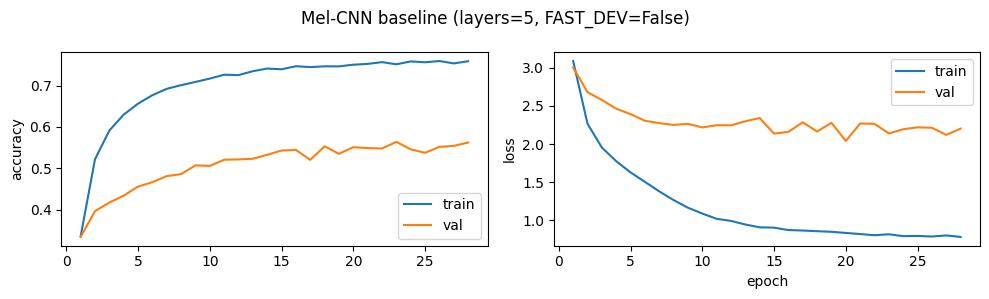

In [10]:
# Training curves
hist = pd.read_csv(RESULTS_DIR / "training_history.csv")
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(hist["epoch"], hist["train_acc"], label="train")
ax[0].plot(hist["epoch"], hist["val_acc"], label="val")
ax[0].set_ylabel("accuracy")
ax[0].legend()
ax[1].plot(hist["epoch"], hist["train_loss"], label="train")
ax[1].plot(hist["epoch"], hist["val_loss"], label="val")
ax[1].set_ylabel("loss")
ax[1].set_xlabel("epoch")
ax[1].legend()
plt.suptitle(f"Mel-CNN baseline (layers={LAYERS}, FAST_DEV={FAST_DEV})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves.png", dpi=120)
plt.show()

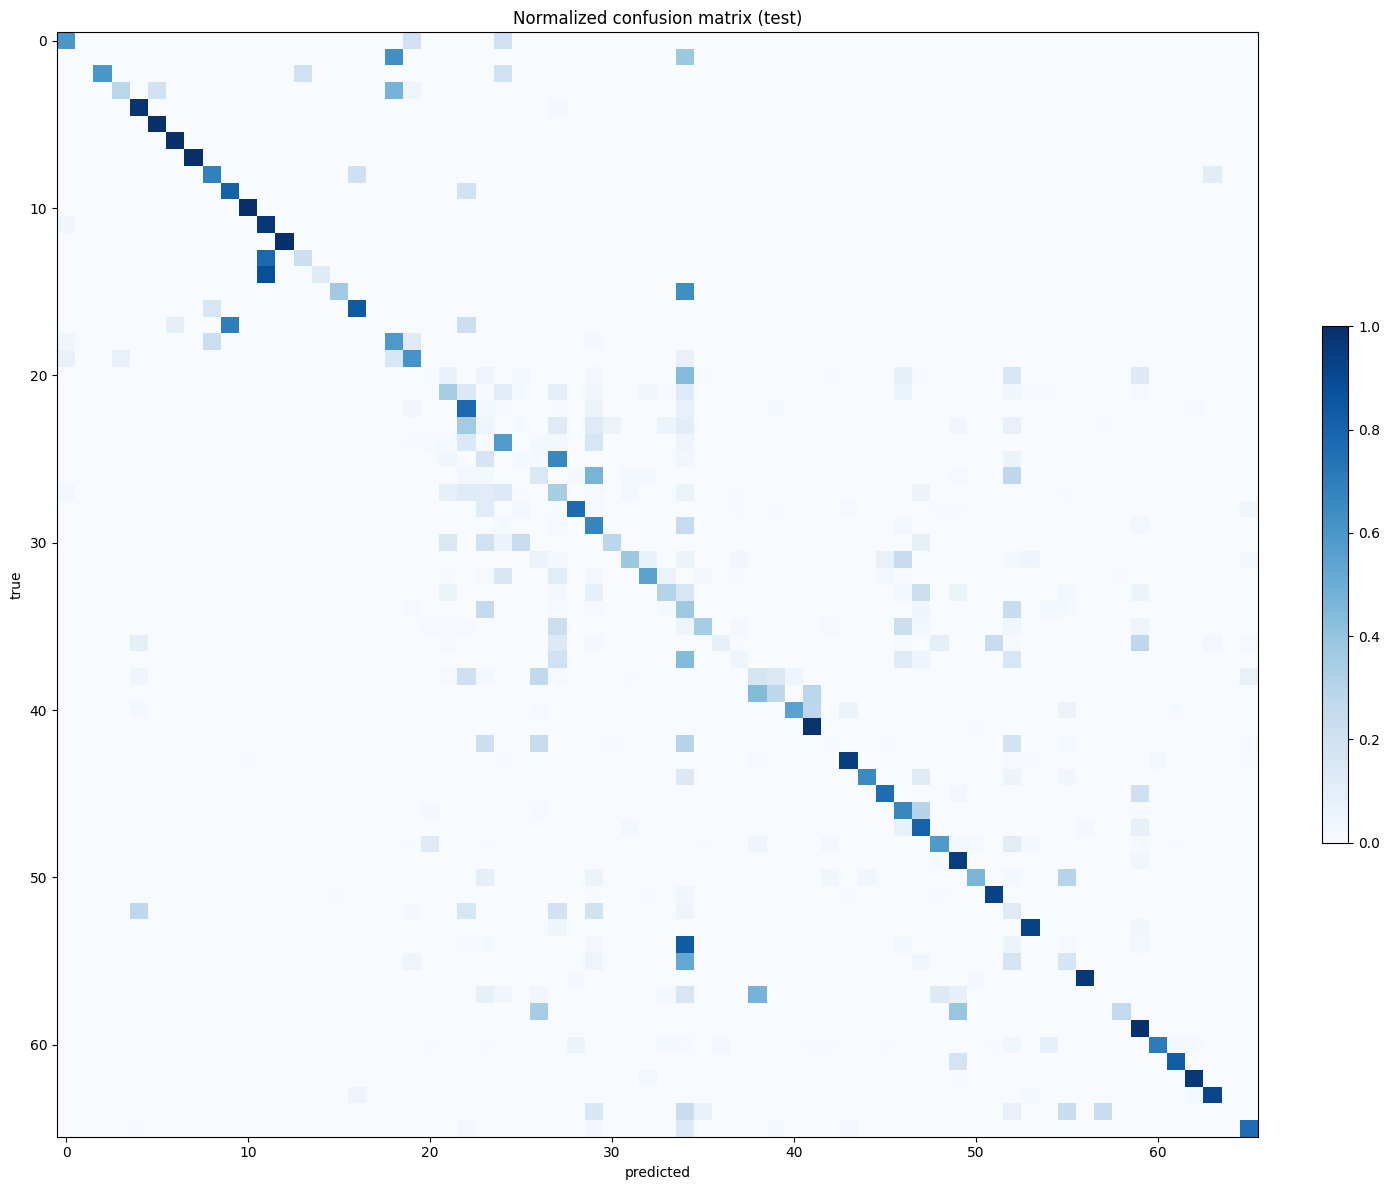

In [11]:
# Confusion matrix (normalized) — large figure like official script
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)), normalize="true")
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, aspect="auto", cmap="Blues")
plt.colorbar(im, ax=ax, fraction=0.02)
ax.set_title("Normalized confusion matrix (test)")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png", dpi=120)
plt.show()

## How to run again (after the Libsndfile fix)

1. **Restart kernel** → **Run All** from the top.
2. Keep `REBUILD_MANIFEST = False` (chunks already built). Keep `VALIDATE_MANIFEST = True`.
3. Wait for **Validate chunks** to finish, then train until you see **`Early stop.`**
4. Run **test** + plot cells last.

Optional terminal cleanup: `python scripts/clean_chunk_manifest.py`

Paper targets (mel, InsectSet66): **~78%** test acc (4 conv), **~82%** (5 conv).